# Description
This notebook explores the named entities that could be linked in Openrefine.

In [2]:
# Import necessary packages
import pandas as pd
import plotly.express as px
from tqdm import tqdm
import numpy as np
import re

In [23]:
df = pd.read_csv("data/persons.csv", sep=";", encoding="utf-8", index_col=0).reset_index(drop=True)
df['gender_GND'] = df['gender_GND'].map({'Weiblich': 'female', 'Männlich': 'male', 'Unbekannt': 'unknown'})

In [27]:
print("Number of linked Entities: ", len(df))

Number of linked Entities:  4410


# Gender plotten

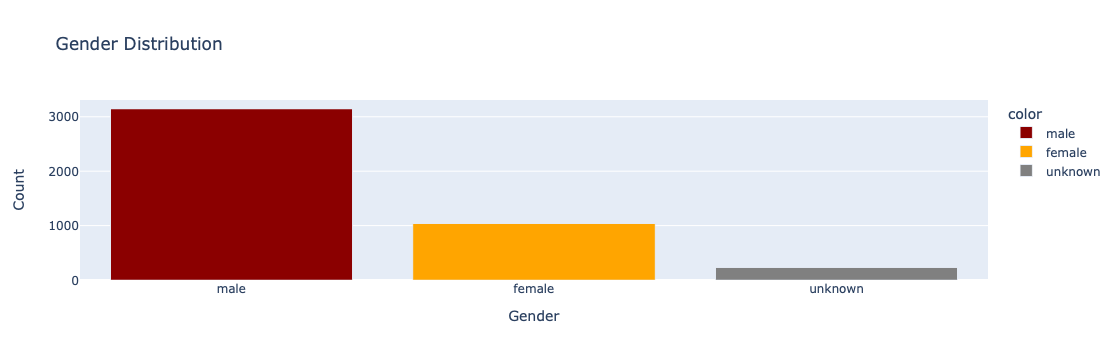

In [24]:

fig = px.bar(df, x=df['gender_GND'].value_counts().index, y=df['gender_GND'].value_counts().values,
             color=df['gender_GND'].value_counts().index,
             labels={'x': 'Gender', 'y': 'Count'},
             title='Gender Distribution',\
            color_discrete_sequence=["darkred", "orange", "grey"])
fig.write_image("figures/person_statistics1.png", scale=2)
fig.show()

In [25]:
print("Proportion of females: ", len(df[df["gender_GND"]== "female"])/len(df))
print("Proportion of males: ", len(df[df["gender_GND"]== "male"])/len(df))

Proportion of females:  0.23492063492063492
Proportion of males:  0.7126984126984127


In [29]:
df

,GND-ID,occupation_GND,birth_GND,gender_GND,death_GND,country_GND
0,118544918,Schriftsteller; Lyriker; Publizist; Nonne,1805-06-22,female,1880-01-12,Frankreich; Deutschland
1,120376555,Literaturwissenschaftler,1959,male,NaN,Deutschland
2,118577166,Nobelpreisträger; Musiker; Intellektueller; Sc...,1875-06-06,male,1955-08-12,Deutschland; Japan; Europa; USA
3,17415769X,Musikwissenschaftler; Hochschullehrer; Museums...,1963,male,NaN,Europa
4,1014025915,NaN,NaN,unknown,NaN,Belgien
...,...,...,...,...,...,...
4405,11859169X,Chemiker; Naturwissenschaftler; Arzt; Alchemis...,1493,male,1541-09-24,Österreich; Europa; Deutschland
4406,118556126,Schriftsteller; Satiriker,NaN,male,NaN,Italien
4407,1027384439,Fiktive Gestalt; Literarische Gestalt,NaN,male,NaN,Australien
4408,118596780,Philosoph; Revolutionär; Volkswirt; Anarchist,1809-01-15,male,1865-01-19,Belgien; Frankreich


# Occupations

In [30]:
alle_berufe = []#

for berufe in tqdm(df["occupation_GND"]):
    if not pd.isna(berufe):
        berufe = berufe.split(";")
        for b in berufe:
            alle_berufe.append(b.strip())
        
alle_berufe = set(alle_berufe)
berufe_counter = {beruf: {"m": 0, "f": 0, "u": 0} for beruf in alle_berufe}


for i in tqdm(range(len(df))):
    berufe = df["occupation_GND"].loc[i]
    geschlecht = df["gender_GND"].loc[i]
    
    if not pd.isna(berufe):
        berufe = berufe.split(";")
        #print(len(berufe))
        for b in berufe:
            
            
            if geschlecht == "male":
                berufe_counter[b.strip()]["m"] += 1
            elif geschlecht == "female":
                berufe_counter[b.strip()]["f"] += 1
            elif geschlecht == "unknown":
                berufe_counter[b.strip()]["u"] += 1         
            
m = []
f = []
u = []

for dictionary in berufe_counter.values():
    m.append(dictionary["m"])
    f.append(dictionary["f"])
    u.append(dictionary["u"])


100%|████████████████████████████████████| 4410/4410 [00:00<00:00, 97656.80it/s]


In [36]:
berufsdf = pd.DataFrame({"Occupation": berufe_counter.keys(), "Female": f, \
                        "Male": m, "Unknown": u})

In [40]:
## Visualize most frequent occupations

In [37]:
berufsdf["Count"] = berufsdf["Female"] + berufsdf["Male"] + berufsdf["Unknown"]
häufigste_berufe = berufsdf.sort_values("Count", ascending=False).reset_index()[0:15]
häufigste_berufe["Occupation"].to_list()

['Schriftsteller',
 'Hochschullehrer',
 'Literaturwissenschaftler',
 'Germanist',
 'Übersetzer',
 'Journalist',
 'Philosoph',
 'Philologe',
 'Drehbuchautor',
 'Historiker',
 'Lyriker',
 'Librettist',
 'Dramatiker',
 'Regisseur',
 'Schauspieler']

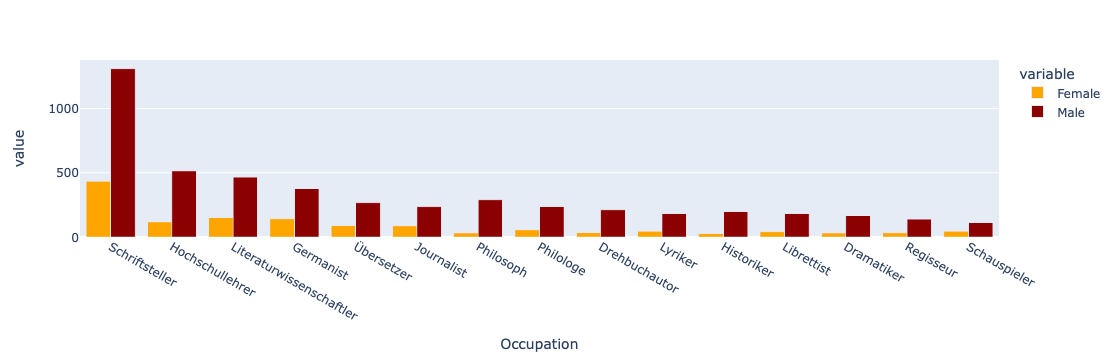

In [45]:

smalldf = berufsdf[berufsdf["Occupation"].isin(häufigste_berufe["Occupation"].to_list())]

fig = px.bar(smalldf, x="Occupation", y=["Female", "Male"], color_discrete_sequence=["orange", "darkred"],\
            barmode="group")
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.write_image("figures/person_statistics2.png", scale=2, height=400, width=900)
fig.show()